In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

Load the dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/HeartDiseaseProject/heart.csv')

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Check the data types & missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Count of missing values one by one
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
# Summary of Statistical(mean,min,max,etc.)
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


target
1    526
0    499
Name: count, dtype: int64


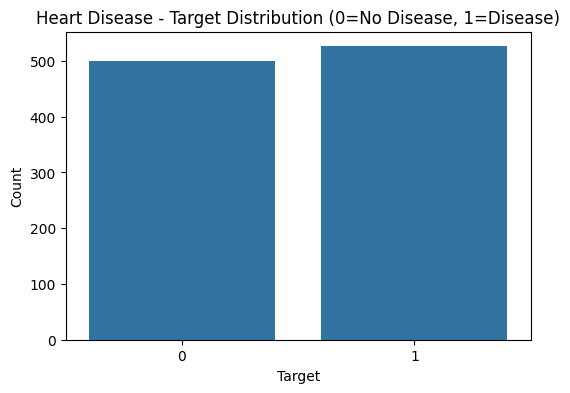

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df['target'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease - Target Distribution (0=No Disease, 1=Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

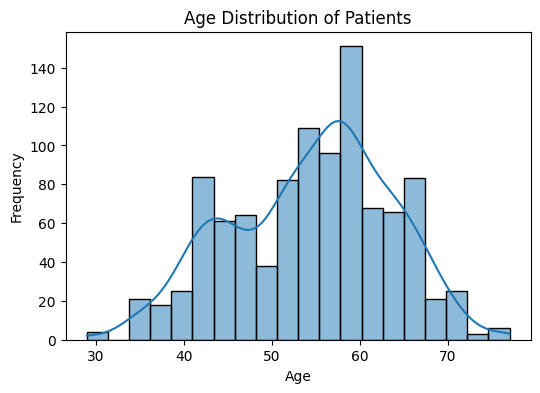

In [8]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

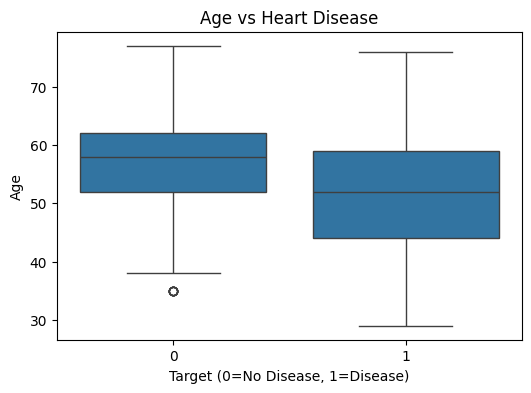

In [9]:
# Age vs Target
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.xlabel('Target (0=No Disease, 1=Disease)')
plt.ylabel('Age')
plt.show()

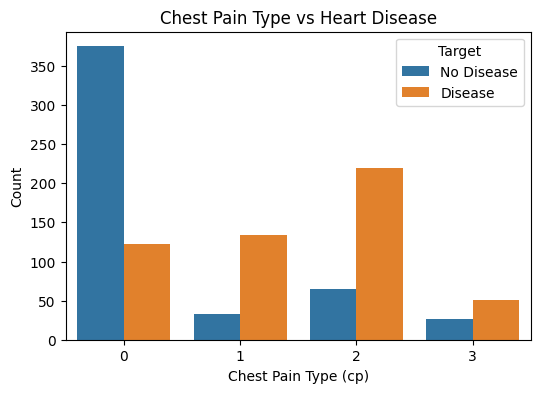

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease','Disease'])
plt.show()

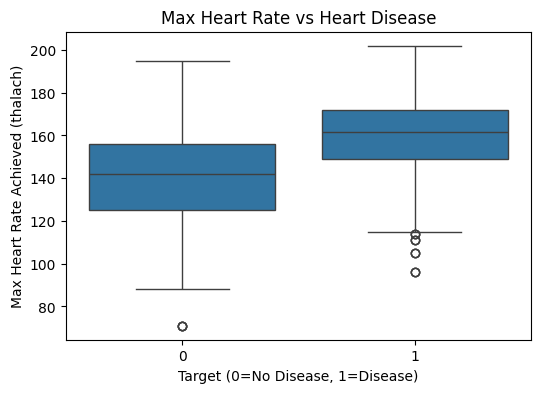

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='thalach', data=df)
plt.title('Max Heart Rate vs Heart Disease')
plt.xlabel('Target (0=No Disease, 1=Disease)')
plt.ylabel('Max Heart Rate Achieved (thalach)')
plt.show()

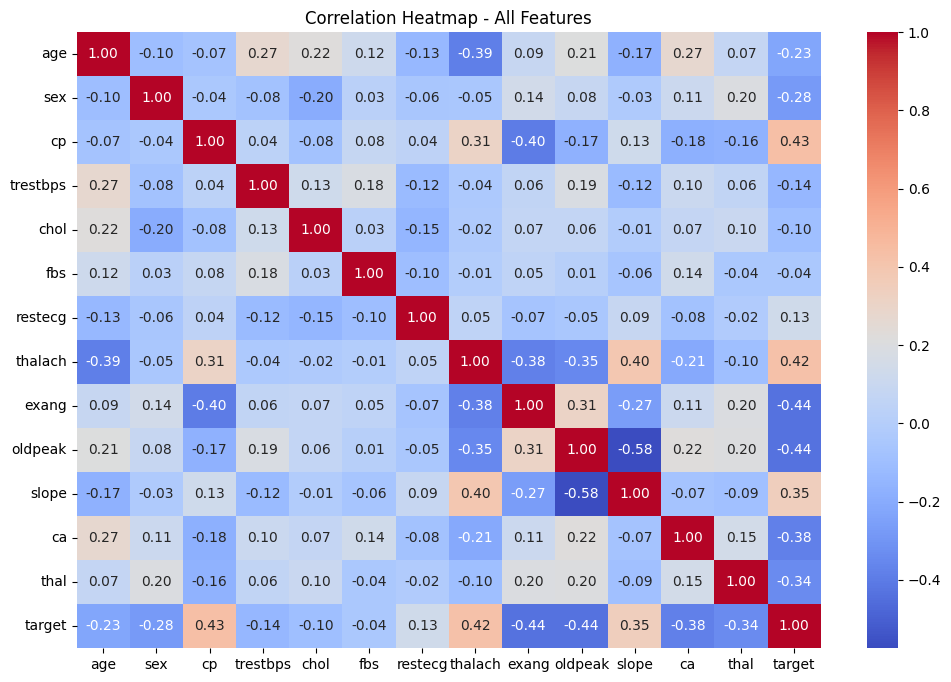

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - All Features')
plt.show()

Data Preprocessing (Train/Test Split + Feature Scaling)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (820, 13)
Test set size: (205, 13)


Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Sample values:")
print(X_train_scaled[:3])

Scaling done. Sample values:
[[-0.58584022  0.65465367  1.008275   -0.77945357 -1.93503098 -0.41403934
  -0.9837419  -1.01909426 -0.72594894 -0.21066121  1.00526437  2.17169136
  -0.54519316]
 [ 1.05147737 -1.52752523 -0.91672034  2.74173173  1.61063407 -0.41403934
   0.9098458   0.20288215  1.37750735 -0.91215236  1.00526437 -0.7254674
  -0.54519316]
 [-0.04006769 -1.52752523  1.008275   -1.34738668  0.44217627 -0.41403934
  -0.9837419   0.77022833 -0.72594894 -0.91215236  1.00526437 -0.7254674
  -0.54519316]]


Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest trained successfully")

Random Forest trained successfully


Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
print("Decision Tree trained successfully")

Decision Tree trained successfully


Compare acuuracy of all models

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_results = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred
}

print(f"{'Model':<22}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
print("-" * 70)

for name, pred in models_results.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<22}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

Model                 Accuracy    Precision   Recall      F1-Score    
----------------------------------------------------------------------
Logistic Regression   0.7951      0.7563      0.8738      0.8108      
Random Forest         0.9854      1.0000      0.9709      0.9852      
Decision Tree         0.9854      1.0000      0.9709      0.9852      


Confusion Matrix - first look the random forest for best model

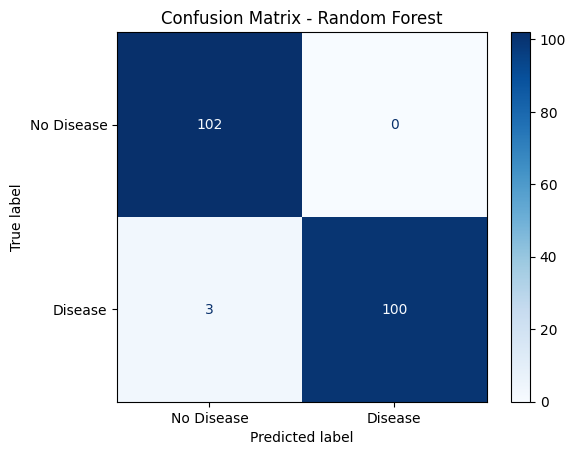

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease','Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Check duplicates

In [20]:
print("Total rows:", df.shape[0])
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 1025
Duplicate rows: 723
Unique rows: 302


Remove duplicates

In [21]:
df_clean = df.drop_duplicates()
print("New shape after removing duplicates:", df_clean.shape)

print(df_clean['target'].value_counts())

New shape after removing duplicates: (302, 14)
target
1    164
0    138
Name: count, dtype: int64


Again Train/Test Split

In [22]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (241, 13)
Test set size: (61, 13)


Again Scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling done")

Scaling done


Again train the models-3 models

In [24]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

print("All models retrained on clean data")

All models retrained on clean data


Again compare results

In [25]:
models_results = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred
}

print(f"{'Model':<22}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
print("-" * 70)

for name, pred in models_results.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<22}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

Model                 Accuracy    Precision   Recall      F1-Score    
----------------------------------------------------------------------
Logistic Regression   0.7705      0.7027      0.8966      0.7879      
Random Forest         0.8361      0.7879      0.8966      0.8387      
Decision Tree         0.7377      0.7407      0.6897      0.7143      


Feature Importance -( Which features have the greatest impact? )

     Feature  Importance
7    thalach    0.138781
2         cp    0.131618
9    oldpeak    0.117095
12      thal    0.101598
11        ca    0.090493
0        age    0.090276
4       chol    0.075677
3   trestbps    0.071152
10     slope    0.055007
8      exang    0.050500
1        sex    0.038310
6    restecg    0.026865
5        fbs    0.012628


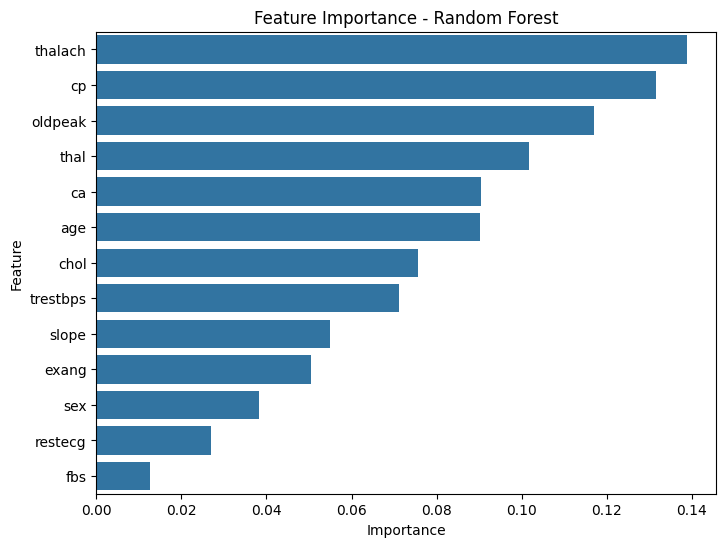

In [26]:
import numpy as np

importances = rf_model.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

Random Forest Confusion Matrix (In final, clean data)

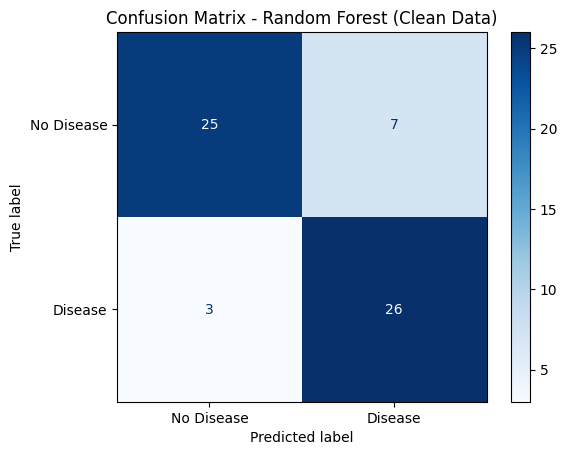

In [27]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease','Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Clean Data)')
plt.show()

Save the Trained Model

In [28]:
import joblib

joblib.dump(rf_model, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Finished Model and Scaler save!")

Finished Model and Scaler save!


Download the files

In [29]:
from google.colab import files

files.download('heart_disease_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Create and download Requirements file

In [30]:
requirements = """streamlit
scikit-learn
pandas
numpy
joblib
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>